In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from algbench import read_as_pandas
from tspn_bnb2.misc.paper_style import FULLWIDEFIGURE, init_params
from tspn_bnb2.schemas import AnnotatedInstance, AnnotatedSolution

init_params()
map_root_name = {
    "LongestEdgePlusFurthestSite": "LEFP",
    "RandomRoot": "Random",
    "OrderRoot": "CHR",
    "LongestPair": "LE",
}

In [2]:
def read_row(row):
    instance = AnnotatedInstance.model_validate_json(
        row["parameters"]["args"]["kwargs"]["instance_json"]
    )
    solution = (
        AnnotatedSolution.model_validate_json(row["result"]["solution"])
        if row["result"]["solution"]
        else None
    )

    if solution is None:
        print(
            row["result"]["error"],
            row["parameters"]["args"]["kwargs"]["instance_name"],
            row["parameters"]["args"]["alg_params"],
        )
        return None

    # if row["parameters"]["args"]["alg_params"]["root"] == "LongestPair":
    #    return None

    instance_name = row["parameters"]["args"]["kwargs"]["instance_name"]

    return {
        "solution": solution,
        "upper_bound": solution.upper_bound,
        "lower_bound": solution.lower_bound,
        "is_optimal": solution.is_optimal,
        "relative_gap": solution.relative_gap,
        "num_discarded_sequences": solution.statistics.get("num_discarded_sequences", 0),
        "num_explored": solution.statistics.get("num_explored", 0),
        "instance_name": instance_name,
        "instance": instance,
        "instance_type": instance.derive_instance_type(),
        "solve_time": row["result"].get("solve_time"),
        "n": instance.num_polygons(),
        "eps": row["parameters"]["args"]["alg_params"]["eps"],
        "root": map_root_name[row["parameters"]["args"]["alg_params"]["root"]],
    }


benchmark = read_as_pandas("results_optimality_gaps_300", read_row)
print("loaded", len(benchmark), "runs")

loaded 5580 runs


In [3]:
benchmark

,solution,upper_bound,lower_bound,is_optimal,relative_gap,num_discarded_sequences,num_explored,instance_name,instance,instance_type,solve_time,n,eps,root
0,"trajectory=<LINESTRING (20.89 7.82, 43.52 14.7...",443.989616,422.084875,False,0.049336,0,29261,kuala_lumpur_n060_seed3530,"polygons=[<POLYGON ((66.61 59.22, 82.99 59.7, ...",OSM,300.336969,60,0.050,LEFP
1,"trajectory=<LINESTRING (17.17 87.8, 24.39 81.1...",444.439577,422.939552,False,0.048376,0,23237,kuala_lumpur_n060_seed3530,"polygons=[<POLYGON ((66.61 59.22, 82.99 59.7, ...",OSM,300.312489,60,0.050,CHR
2,"trajectory=<LINESTRING (20.89 7.82, 43.52 14.7...",443.989616,403.637157,True,0.090886,0,201,kuala_lumpur_n060_seed3530,"polygons=[<POLYGON ((66.61 59.22, 82.99 59.7, ...",OSM,0.473297,60,0.100,LEFP
3,"trajectory=<LINESTRING (17.17 87.8, 24.39 81.1...",444.439577,404.052482,True,0.090872,0,188,kuala_lumpur_n060_seed3530,"polygons=[<POLYGON ((66.61 59.22, 82.99 59.7, ...",OSM,0.544961,60,0.100,CHR
4,"trajectory=<LINESTRING (223.83 53.92, 136.02 7...",753.422040,745.963255,True,0.009900,0,2303,kuala_lumpur_n060_seed4017,"polygons=[<POLYGON ((56.2 45.85, 62.93 60.88, ...",OSM,4.304485,60,0.010,LEFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5575,"trajectory=<LINESTRING (20.55 210.89, 14.51 19...",572.249403,571.682751,True,0.000990,0,105,osaka_n040_seed2534,"polygons=[<POLYGON ((124.57 28.48, 129.14 31.9...",OSM,0.186866,40,0.001,CHR
5576,"trajectory=<LINESTRING (17.688 210.566, 15.36 ...",587.631924,511.852620,True,0.128957,0,19,osaka_n040_seed2534,"polygons=[<POLYGON ((124.57 28.48, 129.14 31.9...",OSM,0.037829,40,0.150,LEFP
5577,"trajectory=<LINESTRING (20.55 210.89, 14.51 19...",575.055487,531.743224,True,0.075318,0,17,osaka_n040_seed2534,"polygons=[<POLYGON ((124.57 28.48, 129.14 31.9...",OSM,0.042707,40,0.150,CHR
5578,"trajectory=<LINESTRING (156.36 191.93, 156.03 ...",688.557443,688.013097,True,0.000791,0,168,osaka_n040_seed3686,"polygons=[<POLYGON ((73.84 189.05, 76.24 201.1...",OSM,0.264526,40,0.001,LEFP


In [4]:
opt_counts = benchmark.groupby(["n", "eps"])["is_optimal"].value_counts().unstack(fill_value=0)
print(opt_counts)

is_optimal  False  True 
n  eps                  
4  0.001        0     16
   0.010        0     16
   0.050        0     16
   0.100        0     16
   0.150        0     16
...           ...    ...
60 0.001       30     68
   0.010       24     74
   0.050       14     84
   0.100        5     93
   0.150        1     97

[165 rows x 2 columns]


In [5]:
# validate that solutions are correct.
for eps in benchmark["eps"].unique():
    n_checks = 0
    current_bench = benchmark[benchmark["eps"] == eps]
    for _, row in current_bench.iterrows():
        solution = row["solution"]
        if solution is None:
            continue
        assert solution.check_feasibility(row["instance"], eps=eps)
        same_instance = current_bench[current_bench["instance_name"] == row["instance_name"]]
        for _, other in same_instance.iterrows():
            if other["solution"] is None:
                continue
            check = solution.plausibility_check(
                other["solution"],
                eps=eps + 0.01,
            )
            assert check["valid"], (
                f"Check failed for {row['instance_name']}, {check} {other['solution']}"
            )
            n_checks += 1

    print(n_checks, "checks succeeded")

2232 checks succeeded
2232 checks succeeded
2232 checks succeeded
2232 checks succeeded
2232 checks succeeded


558
48.946348905563354


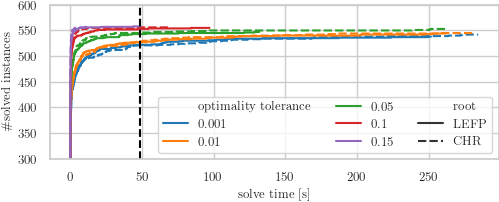

In [7]:
fig, ax = plt.subplots(figsize=FULLWIDEFIGURE)

earliest_all = float("inf")
df = {"solve_time": [], "num_solved": [], "eps": [], "root": []}

print(benchmark["instance_name"].nunique())

last_solved_for_algo = {
    (eps, root): 0 for eps in benchmark["eps"].unique() for root in benchmark["root"].unique()
}

for _, row in benchmark.sort_values(by=["solve_time"], ascending=True).iterrows():
    if not row["is_optimal"]:
        if row["eps"] == 0.001 and row["root"] == "OrderRoot":
            print(row["instance_name"], round((row["solution"].alg_relative_gap - 1) * 100, 2), "%")
        continue
    key = (row["eps"], row["root"])
    last_solved_for_algo[key] += 1
    df["solve_time"].append(row["solve_time"])
    df["num_solved"].append(last_solved_for_algo[key])
    df["eps"].append(row["eps"])
    df["root"].append(row["root"])

    if (
        last_solved_for_algo[key] == benchmark["instance_name"].nunique()
        and row["solve_time"] < earliest_all
    ):
        earliest_all = row["solve_time"]

print(earliest_all)

df = pd.DataFrame(df)

sns.lineplot(
    df,
    ax=ax,
    x="solve_time",
    y="num_solved",
    hue="eps",
    drawstyle="steps-pre",
    style="root",
    palette="tab10",
)

ax.set_ylabel("\\#solved instances")
ax.set_xlabel("solve time [s]")
ax.set_ylim(300, 600)
ax.axvline(earliest_all, color="black", linestyle="dashed")

handles, labels = ax.get_legend_handles_labels()
labels[0] = "optimality tolerance"
ax.legend(handles=handles, labels=labels, ncols=3)

fig.savefig("../plots/rq4_scalability/optimality.pdf", bbox_inches="tight")

In [8]:
for (eps, root), count in last_solved_for_algo.items():
    print(
        root,
        eps,
        round(count / benchmark["instance_name"].nunique() * 100, 2),
        "were solved to optimality",
    )

LEFP 0.05 98.03 were solved to optimality
CHR 0.05 99.1 were solved to optimality
LEFP 0.1 99.46 were solved to optimality
CHR 0.1 99.64 were solved to optimality
LEFP 0.01 97.49 were solved to optimality
CHR 0.01 97.67 were solved to optimality
LEFP 0.001 96.42 were solved to optimality
CHR 0.001 97.13 were solved to optimality
LEFP 0.15 100.0 were solved to optimality
CHR 0.15 99.82 were solved to optimality


In [10]:
import zipfile
from pathlib import Path

original_instances = {}
with zipfile.ZipFile("../../instances/instances_socg.zip", "r") as zip_ref:
    for filename in zip_ref.namelist():
        if not filename.endswith(".json"):
            continue
        original_instances[Path(filename).stem] = AnnotatedInstance.model_validate_json(
            zip_ref.open(filename).read()
        )

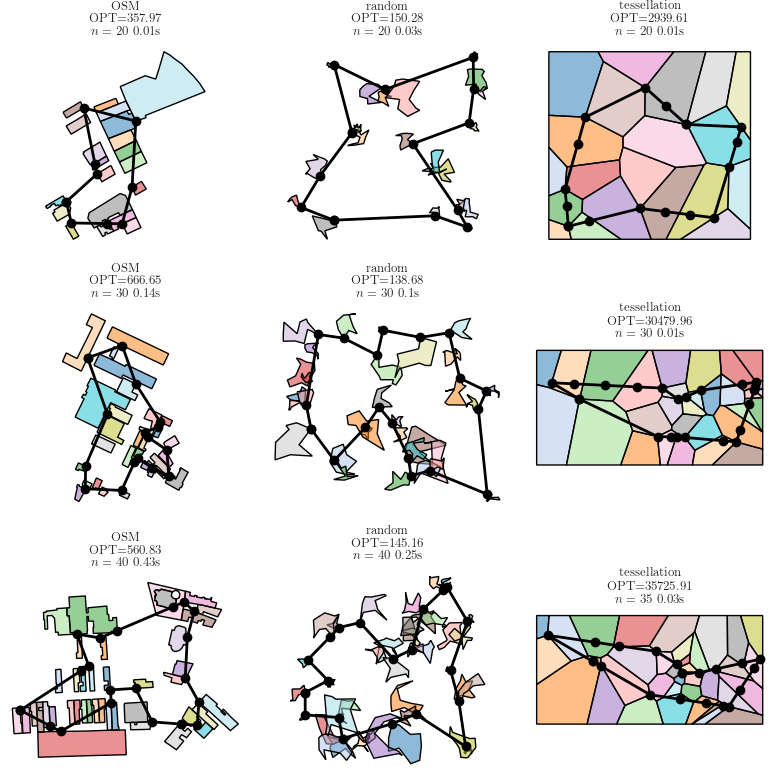

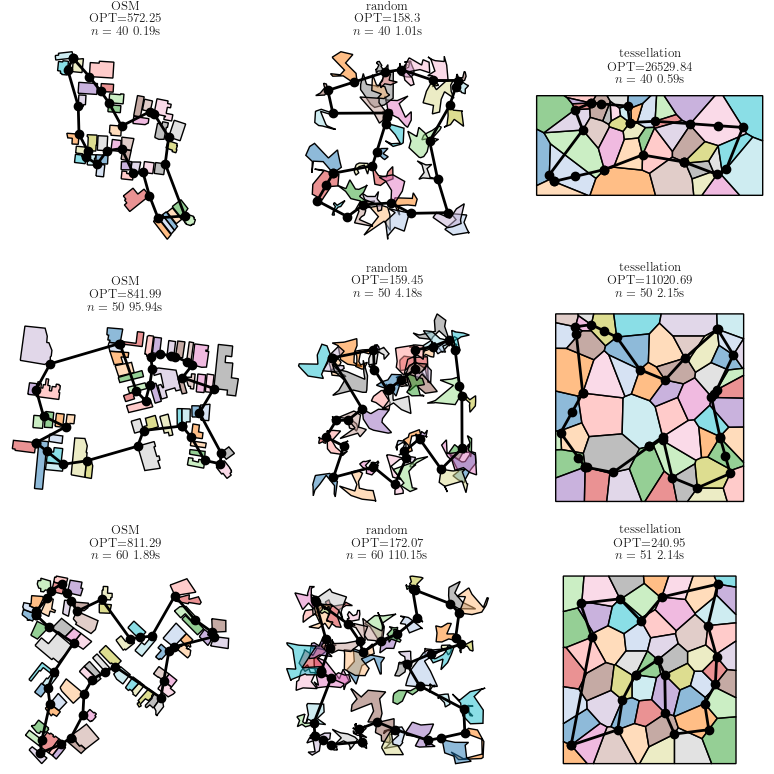

In [11]:
from shapely.plotting import plot_line, plot_polygon

for seed, min_n in zip([1337, 1337], [20, 40]):
    fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(8, 8))

    bench = benchmark[
        (benchmark["root"] == "CHR") & (benchmark["eps"] == 0.001) & (benchmark["is_optimal"])
    ]

    cmap = plt.get_cmap("tab20")
    i = 0

    for n in [min_n, min_n + 10, min_n + 20]:
        for instance_type in benchmark["instance_type"].unique():
            for _, entry in (
                bench[
                    (bench["n"] <= n)
                    & (bench["n"] >= max(min_n, n - 9))
                    & (bench["instance_type"] == instance_type)
                ]
                .sample(1, random_state=seed)
                .iterrows()
            ):
                ax = axs[i // 3, i % 3]
                i += 1
                orig_instance = original_instances[entry["instance_name"]]
                for j, poly in enumerate(orig_instance.polygons):
                    color = cmap(j % cmap.N)
                    face_rgba = (*color[:3], 0.5)
                    plot_polygon(
                        poly, ax=ax, facecolor=face_rgba, edgecolor="black", add_points=False
                    )

                plot_line(entry["solution"].trajectory, ax=ax, color="black")

                n_digits = 2
                if round(entry["solve_time"], n_digits) == 0:
                    n_digits += 1

                ax.set_title(
                    f"{entry['instance_type']}\n"
                    f"OPT={round(entry['upper_bound'], 2)}\n"
                    f"$n={orig_instance.num_polygons()}$ {round(entry['solve_time'], n_digits)}s"
                )

                ax.set_aspect("equal")
                ax.set_axis_off()

    fig.tight_layout()
    fig.savefig(f"../plots/examples/grid_3x3_{min_n}_{seed}.pdf", bbox_inches="tight")

In [12]:
# find a solution with few points but any polygons:

bench = benchmark[
    (benchmark["root"] == "OrderRoot")
    & (benchmark["n"] == 40)
    & (benchmark["eps"] == 0.001)
    & (benchmark["is_optimal"])
]
cmap = plt.get_cmap("tab20")

for _, entry in bench.iterrows():
    if len(entry["solution"].trajectory.coords) < 20:
        fig, ax = plt.subplots(figsize=(6, 6))

        orig_instance = original_instances[entry["instance_name"]]
        for j, poly in enumerate(orig_instance.polygons):
            color = cmap(j % cmap.N)
            face_rgba = (*color[:3], 0.5)
            plot_polygon(poly, ax=ax, facecolor=face_rgba, edgecolor="black", add_points=False)

        plot_line(entry["solution"].trajectory, ax=ax, color="black")

        ax.set_aspect("equal")
        ax.set_axis_off()
        fig.tight_layout()

        fig.savefig(
            f"../plots/examples/simplification/{entry['instance_name']}.pdf", bbox_inches="tight"
        )

In [13]:
bench = benchmark[
    (benchmark["root"] == "OrderRoot") & (benchmark["eps"] == 0.001) & (benchmark["is_optimal"])
]

cmap = plt.get_cmap("tab20")
i = 0

for _n in [60]:
    for _, entry in bench[(bench["n"] >= 50) & (bench["instance_type"] == "random")].iterrows():
        fig, ax = plt.subplots(figsize=(6, 6))

        i += 1
        orig_instance = original_instances[entry["instance_name"]]
        for j, poly in enumerate(orig_instance.polygons):
            color = cmap(j % cmap.N)
            face_rgba = (*color[:3], 0.5)
            plot_polygon(poly, ax=ax, facecolor=face_rgba, edgecolor="black", add_points=False)

        plot_line(entry["solution"].trajectory, ax=ax, color="black")

        ax.set_aspect("equal")
        ax.set_axis_off()
        fig.tight_layout()
        fig.savefig(
            f"../plots/examples/opt_50-60/{entry['instance_name']}_{orig_instance.num_polygons()}_{round(entry['solve_time'])}s.pdf",
            bbox_inches="tight",
        )